# Experiment 1 — Transformation Recovery

**Goal:** Given paired point clouds $P = T_1(S)$ and $Q = T_2(S)$ (both observed, matching known), fit
$$f(p) = Rp + t + u(p)$$
and check whether it recovers the ground-truth composed transformation $T_2 \circ T_1^{-1}$.

See `Notes/Transformation Recovery.md` for problem formulation.

In [59]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt

from point_cloud import PointCloud
from transformation import RigidTransformation
from elastic_transformation import ElasticTransformation
plt.style.use("seaborn-v0_8-whitegrid")

## 1. Synthetic data generation

- $S$: random point cloud (irregular, not a lattice)
- $T_1, T_2$: random rigid transformations with small per-point Gaussian noise
- $P = T_1(S)$, $Q = T_2(S)$  — matching is known ($p_i \leftrightarrow q_i$)

In [60]:
SEED = 42
N = 2000         # number of nuclei
NOISE_STD = 3.0  # per-point noise on each observation (simulates detection jitter)
T_SCALE = 8.0    # translation magnitude

np.random.seed(SEED)

# Irregular source cloud (non-lattice)
S = PointCloud(np.random.uniform(low=-30, high=30, size=(N, 3)))

T1 = RigidTransformation.random(noise_std=NOISE_STD, t_scale=T_SCALE)
T2 = RigidTransformation.random(noise_std=NOISE_STD, t_scale=T_SCALE)

P = T1.apply(S)
Q = T2.apply(S)

print(f"S: {S}")
print(f"T1: {T1}")
print(f"T2: {T2}")
print(f"P: {P}")
print(f"Q: {Q}")

S: PointCloud(n=2000)
T1: RigidTransformation(rot=149.5°, t_norm=5.17)
T2: RigidTransformation(rot=153.1°, t_norm=5.87)
P: PointCloud(n=2000)
Q: PointCloud(n=2000)


## 2. Ground truth

Because $p_i = T_1(s_i)$ and $q_i = T_2(s_i)$, the ideal map (ignoring noise) is
$$f_{\mathrm{gt}}(p) = T_2 \circ T_1^{-1}(p)$$
giving
$$R_{\mathrm{gt}} = R_2 R_1^\top, \quad t_{\mathrm{gt}} = t_2 - R_{\mathrm{gt}}\, t_1$$
and $u_{\mathrm{gt},i} \approx \varepsilon_{2,i} - R_{\mathrm{gt}}\, \varepsilon_{1,i}$ (observation noise).

In [61]:
T_gt = T2.compose_with_inverse(T1)
R_gt, t_gt = T_gt.R, T_gt.t

print("Ground-truth rotation matrix R_gt:")
print(np.round(R_gt, 4))
print(f"\nGround-truth translation t_gt: {np.round(t_gt, 4)}")
print(f"Rotation angle: {np.degrees(np.arccos(np.clip((np.trace(R_gt)-1)/2, -1, 1))):.2f}°")

Ground-truth rotation matrix R_gt:
[[ 0.9705 -0.1231  0.2075]
 [ 0.1524  0.9795 -0.132 ]
 [-0.187   0.1597  0.9693]]

Ground-truth translation t_gt: [-7.7912 -4.4575 -0.117 ]
Rotation angle: 16.34°


In [62]:
def rotation_angle_error(R1: np.ndarray, R2: np.ndarray) -> float:
    """Angular distance between two SO(3) matrices in degrees."""
    cos = np.clip((np.trace(R1.T @ R2) - 1) / 2, -1.0, 1.0)
    return float(np.degrees(np.arccos(cos)))

# Baseline: rigid-only fit (no residual field)
rigid_fit = RigidTransformation.fit(P, Q)
print("=== Baseline: rigid SVD fit ===")
print(f"Rotation error : {rotation_angle_error(R_gt, rigid_fit.R):.4f}°")
print(f"Translation err: {np.linalg.norm(t_gt - rigid_fit.t):.4f}")
Q_rigid = rigid_fit.apply(P)
residuals_rigid = np.linalg.norm(Q_rigid.points - Q.points, axis=1)
print(f"Mean point residual: {residuals_rigid.mean():.4f}")

=== Baseline: rigid SVD fit ===
Rotation error : 0.2441°
Translation err: 0.3152
Mean point residual: 6.7949


## 3. Fit ElasticTransformation

Minimises
$$\min_{R,\,t,\,u}\; \sum_i \|Rp_i + t + u(p_i) - q_i\|^2 + \lambda_1 \sum_i \|u(p_i)\|^2 + \lambda_2 \sum_{i,j} w_{ij}\|u(p_i) - u(p_j)\|^2$$
with Adam, using the 6D rotation representation of Zhou et al. (2019).

In [63]:
f = ElasticTransformation.fit(
    P, Q,
    lambda1=0.1,
    lambda2=0.01,
    n_iter=200,
    lr=1e-2,
    k_neighbors=10,
    verbose=True,
    log_every=1,
)

  iter    1 | loss=54.14852 | data=54.14852 | u_mag=0.00000 | reg=0.00000
  iter    2 | loss=53.97306 | data=53.94548 | u_mag=0.00030 | reg=2.75423
  iter    3 | loss=53.96546 | data=53.87940 | u_mag=0.00101 | reg=8.59524
  iter    4 | loss=53.73873 | data=53.57670 | u_mag=0.00204 | reg=16.18322
  iter    5 | loss=53.71055 | data=53.46779 | u_mag=0.00328 | reg=24.24330
  iter    6 | loss=53.67355 | data=53.35331 | u_mag=0.00466 | reg=31.97710
  iter    7 | loss=53.56795 | data=53.17724 | u_mag=0.00614 | reg=39.01000
  iter    8 | loss=53.47888 | data=53.02621 | u_mag=0.00769 | reg=45.19005
  iter    9 | loss=53.44697 | data=52.94119 | u_mag=0.00929 | reg=50.48450
  iter   10 | loss=53.43355 | data=52.88310 | u_mag=0.01091 | reg=54.93613
  iter   11 | loss=53.39034 | data=52.80272 | u_mag=0.01257 | reg=58.63586
  iter   12 | loss=53.32728 | data=52.70892 | u_mag=0.01425 | reg=61.69347
  iter   13 | loss=53.27784 | data=52.63406 | u_mag=0.01595 | reg=64.21825
  iter   14 | loss=53.25438 

## 4. Evaluation

In [64]:
rot_err   = rotation_angle_error(R_gt, f.R)
t_err     = np.linalg.norm(t_gt - f.t)
u_mag     = np.linalg.norm(f.u, axis=1).mean()
Q_pred    = f.apply(P)
residuals = np.linalg.norm(Q_pred.points - Q.points, axis=1)

print("=== ElasticTransformation ===")
print(f"Rotation error     : {rot_err:.4f}°")
print(f"Translation error  : {t_err:.4f}")
print(f"Mean |u_i|         : {u_mag:.4f}")
print(f"Mean point residual: {residuals.mean():.4f}")
print(f"Max  point residual: {residuals.max():.4f}")
print()
print("=== Comparison ===")
print(f"Rigid residual (mean): {residuals_rigid.mean():.4f}")
print(f"Elastic residual (mean): {residuals.mean():.4f}")

=== ElasticTransformation ===
Rotation error     : 0.2277°
Translation error  : 0.2835
Mean |u_i|         : 0.4739
Mean point residual: 6.5859
Max  point residual: 17.7095

=== Comparison ===
Rigid residual (mean): 6.7949
Elastic residual (mean): 6.5859


## 5. Visualisation

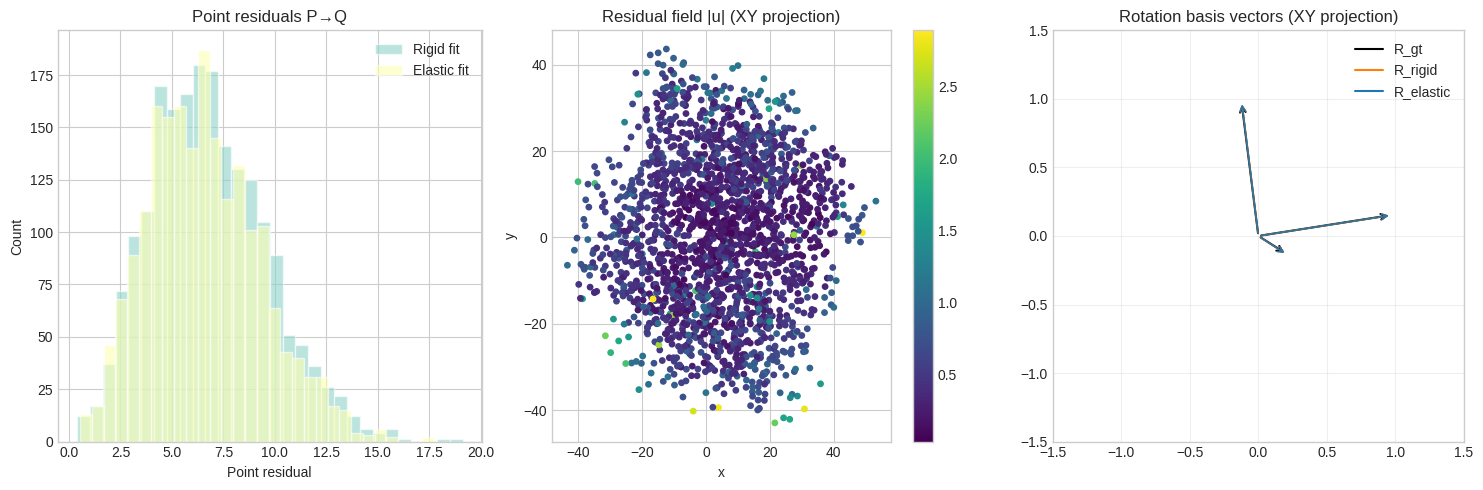

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# --- Residual histogram ---
ax = axes[0]
ax.hist(residuals_rigid, bins=30, alpha=0.6, label='Rigid fit')
ax.hist(residuals,       bins=30, alpha=0.6, label='Elastic fit')
ax.set_xlabel('Point residual')
ax.set_ylabel('Count')
ax.set_title('Point residuals P→Q')
ax.legend()

# --- Residual field u magnitude ---
ax = axes[1]
u_norms = np.linalg.norm(f.u, axis=1)
sc = ax.scatter(P.points[:, 0], P.points[:, 1], c=u_norms, cmap='viridis', s=15)
plt.colorbar(sc, ax=ax)
ax.set_title('Residual field |u| (XY projection)')
ax.set_xlabel('x'); ax.set_ylabel('y')

# --- Recovered vs ground-truth rotation comparison ---
ax = axes[2]
labels = ['R_gt', 'R_rigid', 'R_elastic']
matrices = [R_gt, rigid_fit.R, f.R]
colors = ['black', 'tab:orange', 'tab:blue']
origin = np.zeros(3)
ax.set_aspect('equal')
for label, R, color in zip(labels, matrices, colors):
    for i, axis_vec in enumerate(R.T):  # columns = basis vectors
        ax.annotate('', xy=axis_vec[:2], xytext=origin[:2],
                    arrowprops=dict(arrowstyle='->', color=color, lw=1.5 if label=='R_gt' else 1.0))
    ax.plot([], [], color=color, label=label)
ax.set_xlim(-1.5, 1.5); ax.set_ylim(-1.5, 1.5)
ax.set_title('Rotation basis vectors (XY projection)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('experiment_1_results.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Parameter sensitivity sweep

Vary $\lambda_1$ and $\lambda_2$ to see their effect on rotation recovery and residual magnitude.

In [66]:
configs = [
    dict(lambda1=0.0,  lambda2=0.0),
    dict(lambda1=0.1,  lambda2=0.0),
    dict(lambda1=0.0,  lambda2=0.01),
    dict(lambda1=0.1,  lambda2=0.01),
    dict(lambda1=1.0,  lambda2=0.1),
]

rows = []
for cfg in configs:
    fi = ElasticTransformation.fit(
        P, Q, **cfg, n_iter=1000, lr=1e-2, verbose=False
    )
    res = np.linalg.norm(fi.apply(P).points - Q.points, axis=1).mean()
    rows.append({
        'λ1': cfg['lambda1'], 'λ2': cfg['lambda2'],
        'rot_err (°)': round(rotation_angle_error(R_gt, fi.R), 3),
        't_err': round(np.linalg.norm(t_gt - fi.t), 4),
        'mean|u|': round(np.linalg.norm(fi.u, axis=1).mean(), 4),
        'mean_residual': round(res, 4),
    })

# Print as a table
keys = list(rows[0].keys())
header = '  '.join(f'{k:>14}' for k in keys)
print(header)
print('-' * len(header))
for row in rows:
    print('  '.join(f'{str(v):>14}' for v in row.values()))

            λ1              λ2     rot_err (°)           t_err         mean|u|   mean_residual
----------------------------------------------------------------------------------------------
           0.0             0.0           0.266          0.3458          6.1932          0.6591
           0.1             0.0           0.236          0.3332          5.7498          1.0691
           0.0            0.01           0.304          0.2209          0.5462          6.5642
           0.1            0.01           0.293          0.2988          0.5025          6.5684
           1.0             0.1           0.259          0.3151          0.0957          6.7614
